In [1]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import torch
import tensorflow as tf
import math
import re
import collections
from typing import Dict, List, Tuple
import os, pathlib, shutil, random


In [3]:
# Quick health check to prove it works:
print("Is PyTorch utilizing the GPU?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device Name:", torch.cuda.get_device_name(0))

Is PyTorch utilizing the GPU?: False


### Load Dataset

In [4]:
# Raw IMBD Dataset
zip_path = keras.utils.get_file(origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz", fname="imdb",extract=True)
imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"
imdb_extract_dir

WindowsPath('C:/Users/PRASHANTH N/.keras/datasets/imdb/aclImdb')

In [5]:
# Directory Structure
for path in imdb_extract_dir.glob("*/*"):
    if path.is_dir():
        print(path)

C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\test\neg
C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\test\pos
C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\train\neg
C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\train\pos
C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\train\unsup


In [6]:
# Preview a single IMBD Review
print(open(imdb_extract_dir / "train" / "pos" / "4077_10.txt", "r").read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [7]:
for path in imdb_extract_dir.glob("*/*"):
    if path.is_dir():
        print(path, end = " : ")
        print(sum([1 for file in path.glob("*.txt")]))

C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\test\neg : 12500
C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\test\pos : 12500
C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\train\neg : 12500
C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\train\pos : 12500
C:\Users\PRASHANTH N\.keras\datasets\imdb\aclImdb\train\unsup : 50000


### Data Preprocessing

In [8]:
# Train - Test - Val Split Placeholder Location
train_dir = pathlib.Path("imdb_train")
test_dir = pathlib.Path("imdb_test")
val_dir = pathlib.Path("imdb_val")

In [9]:
# shutil.copytree(imdb_extract_dir / "test", test_dir) # Move Test Folder into Test dir

In [10]:
# 20% of Train data into Val Dir
val_percentage = 0.2
"""
for category in ("neg", "pos"):
    src_dir = imdb_extract_dir / "train" / category
    src_files = os.listdir(src_dir)
    random.Random(1337).shuffle(src_files)
    num_val_samples = int(len(src_files) * val_percentage)
    os.makedirs(val_dir / category)
    for file in src_files[:num_val_samples]:
        shutil.copy(src_dir / file, val_dir / category / file)
    os.makedirs(train_dir / category)
    for file in src_files[num_val_samples:]:
        shutil.copy(src_dir / file, train_dir / category / file)
"""

'\nfor category in ("neg", "pos"):\n    src_dir = imdb_extract_dir / "train" / category\n    src_files = os.listdir(src_dir)\n    random.Random(1337).shuffle(src_files)\n    num_val_samples = int(len(src_files) * val_percentage)\n    os.makedirs(val_dir / category)\n    for file in src_files[:num_val_samples]:\n        shutil.copy(src_dir / file, val_dir / category / file)\n    os.makedirs(train_dir / category)\n    for file in src_files[num_val_samples:]:\n        shutil.copy(src_dir / file, train_dir / category / file)\n'

In [11]:
# Loading the IMDb dataset for use with Keras
batch_size = 32
train_ds = keras.utils.text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds = keras.utils.text_dataset_from_directory(val_dir, batch_size=batch_size)
test_ds = keras.utils.text_dataset_from_directory(test_dir, batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


### Set Models

#### Bag of Word Model

##### Word Embedding

In [12]:
max_tokens = 20_000
text_vectorization = keras.layers.TextVectorization(max_tokens=max_tokens, split="whitespace", output_mode="multi_hot", )
train_ds_no_labels = train_ds.map(lambda x, y: x)
text_vectorization.adapt(train_ds_no_labels)
print(text_vectorization)



<TextVectorization name=text_vectorization, built=False>


In [13]:
bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [14]:
x, y = next(bag_of_words_train_ds.as_numpy_iterator())
x.shape, y.shape

((32, 20000), (32,))

In [15]:
x[0]

array([1, 1, 1, ..., 0, 0, 0], shape=(20000,))

In [16]:
y

array([1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 0], dtype=int32)

##### Model

In [17]:
# Building a bag-of-words regression model
def build_linear_classifier(max_tokens, name):
    inputs = keras.Input(shape=(max_tokens,))
    outputs = keras.layers.Dense(1, activation="sigmoid")(inputs)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"], )
    return model

model = build_linear_classifier(max_tokens, "bag_of_words_classifier")
model.summary()

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        20,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

##### Training

In [18]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
history = model.fit(
    bag_of_words_train_ds,
    validation_data=bag_of_words_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8406 - loss: 0.4589 - val_accuracy: 0.8782 - val_loss: 0.3604
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9083 - loss: 0.2934 - val_accuracy: 0.8886 - val_loss: 0.3067
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9293 - loss: 0.2358 - val_accuracy: 0.8920 - val_loss: 0.2853
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9424 - loss: 0.2005 - val_accuracy: 0.8934 - val_loss: 0.2731
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9531 - loss: 0.1751 - val_accuracy: 0.8942 - val_loss: 0.2667
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9604 - loss: 0.1552 - val_accuracy: 0.8956 - val_loss: 0.2638
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9662 - loss: 0.1389 - val_accuracy: 0.8966 - val_loss: 0.2621
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9714 - loss: 0.1252 - val_accu

##### Evaluate

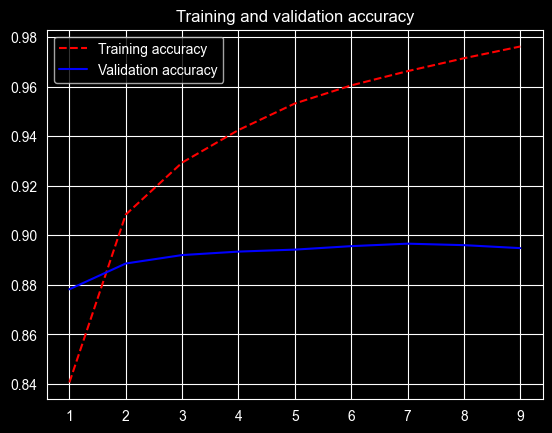

In [19]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [20]:
test_loss, test_acc = model.evaluate(bag_of_words_test_ds)
test_loss, test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8880 - loss: 0.2804


(0.280436247587204, 0.8879600167274475)

#### Bigram Model

##### Word Embedding

In [21]:
# Applying a bigram encoding to the IMDb reviews
max_tokens = 30_000
text_vectorization = keras.layers.TextVectorization(max_tokens=max_tokens, split="whitespace", output_mode="multi_hot", ngrams=2)
text_vectorization.adapt(train_ds_no_labels)
text_vectorization

<TextVectorization name=text_vectorization_1, built=False>

In [22]:
bigram_train_ds = train_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=8)
bigram_val_ds = val_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=8)
bigram_test_ds = test_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=8)

In [23]:
x, y = next(bigram_train_ds.as_numpy_iterator())
x.shape, y.shape

((32, 30000), (32,))

In [24]:
x[0]

array([1, 1, 1, ..., 0, 0, 0], shape=(30000,))

In [25]:
y

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 1], dtype=int32)

In [26]:
text_vectorization.get_vocabulary()[100:108]

[np.str_('first'),
 np.str_('most'),
 np.str_('him'),
 np.str_('dont'),
 np.str_('it was'),
 np.str_('then'),
 np.str_('one of'),
 np.str_('for the')]

##### Model

In [27]:
# Building a bag-of-words regression model
def build_linear_classifier(max_tokens, name):
    inputs = keras.Input(shape=(max_tokens,))
    outputs = keras.layers.Dense(1, activation="sigmoid")(inputs)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"], )
    return model

model = build_linear_classifier(max_tokens, "bigram_classifier")
model.summary()

Model: "bigram_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        30,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,001 (117.19 KB)

 Trainable params: 30,001 (117.19 KB)

 Non-trainable params: 0 (0.00 B)

##### Training

In [28]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    restore_best_weights=True,
    patience=2,
)
model.fit(
    bigram_train_ds,
    validation_data=bigram_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8668 - loss: 0.3983 - val_accuracy: 0.8924 - val_loss: 0.3067
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9365 - loss: 0.2228 - val_accuracy: 0.9014 - val_loss: 0.2675
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9606 - loss: 0.1637 - val_accuracy: 0.9050 - val_loss: 0.2534
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9752 - loss: 0.1273 - val_accuracy: 0.9068 - val_loss: 0.2474
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9843 - loss: 0.1015 - val_accuracy: 0.9066 - val_loss: 0.2458
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9897 - loss: 0.0820 - val_accuracy: 0.9062 - val_loss: 0.2471
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9936 - loss: 0.0670 - val_accuracy: 0.9058 - val_loss: 0.2497


##### Evaluate

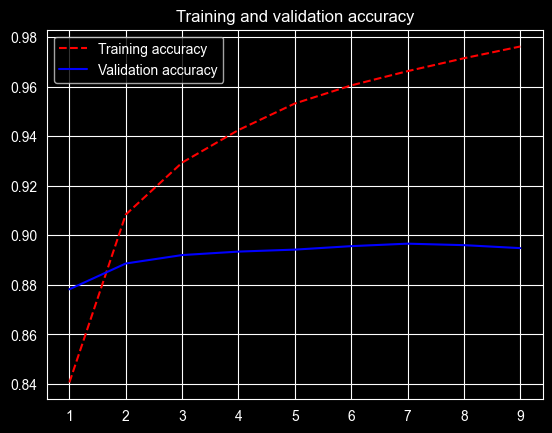

In [29]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [30]:
test_loss, test_acc = model.evaluate(bigram_test_ds)
test_loss, test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9008 - loss: 0.2508


(0.25082850456237793, 0.9007999897003174)

### Sequence Models

#### Data preprocess


In [31]:
# Padding IMDb reviews to a fixed sequence length
max_length = 600
max_tokens = 30_000
text_vectorization = keras.layers.TextVectorization(max_tokens=max_tokens, split="whitespace", output_mode="int", output_sequence_length=max_length, )
text_vectorization.adapt(train_ds_no_labels)

In [32]:
sequence_train_ds = train_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=8)
sequence_val_ds = val_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=8)
sequence_test_ds = test_ds.map(lambda x, y: (text_vectorization(x), y), num_parallel_calls=8)

In [33]:
x, y = next(sequence_test_ds.as_numpy_iterator())
x.shape, y.shape

((32, 600), (32,))

In [34]:
y

array([0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1], dtype=int32)

In [35]:
x

array([[  21,   54, 5731, ...,    0,    0,    0],
       [2175, 1055,   16, ...,    0,    0,    0],
       [  48,    4,  386, ...,    0,    0,    0],
       ...,
       [   4,  183,  134, ...,    0,    0,    0],
       [   1,  172, 1472, ...,    0,    0,    0],
       [   4,  351,  312, ...,    0,    0,    0]], shape=(32, 600))

#### Model

In [36]:
# Building a one-hot encoding layer with Keras ops
class OneHotEncoding(keras.Layer):
    def __init__(self, depth, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth

    def call(self, inputs):
        flat_inputs = keras.ops.reshape(keras.ops.cast(inputs, "int"), [-1])
        one_hot_vectors = keras.ops.eye(self.depth)
        outputs = keras.ops.take(one_hot_vectors, flat_inputs, axis=0)
        return keras.ops.reshape(outputs, keras.ops.shape(inputs) + (self.depth,))

one_hot_encoding = OneHotEncoding(max_tokens)
one_hot_encoding

<OneHotEncoding name=one_hot_encoding, built=False>

In [37]:
# Building an LSTM sequence model
hidden_dim = 64
inputs = keras.Input(shape=(max_length,), dtype="int32")
x = one_hot_encoding(inputs)
x = keras.layers.Bidirectional(keras.layers.LSTM(hidden_dim))(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_one_hot")
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "lstm_with_one_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 600)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ one_hot_encoding                │ (None, 600, 30000)     │             0 │
│ (OneHotEncoding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │    15,393,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,393,409 (58.72 MB)

 Trainable params: 15,393,409 (58.72 MB)

 Non-trainable params: 0 (0.00 B)

#### Training

In [ ]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=2,
    callbacks=[early_stopping],
)
# Shit takes 2 hr per epoch and exceed ram usage

Epoch 1/2
  5/625 ━━━━━━━━━━━━━━━━━━━━ 2:40:01 15s/step - accuracy: 0.5170 - loss: 0.6923